Student Performance Dashboard


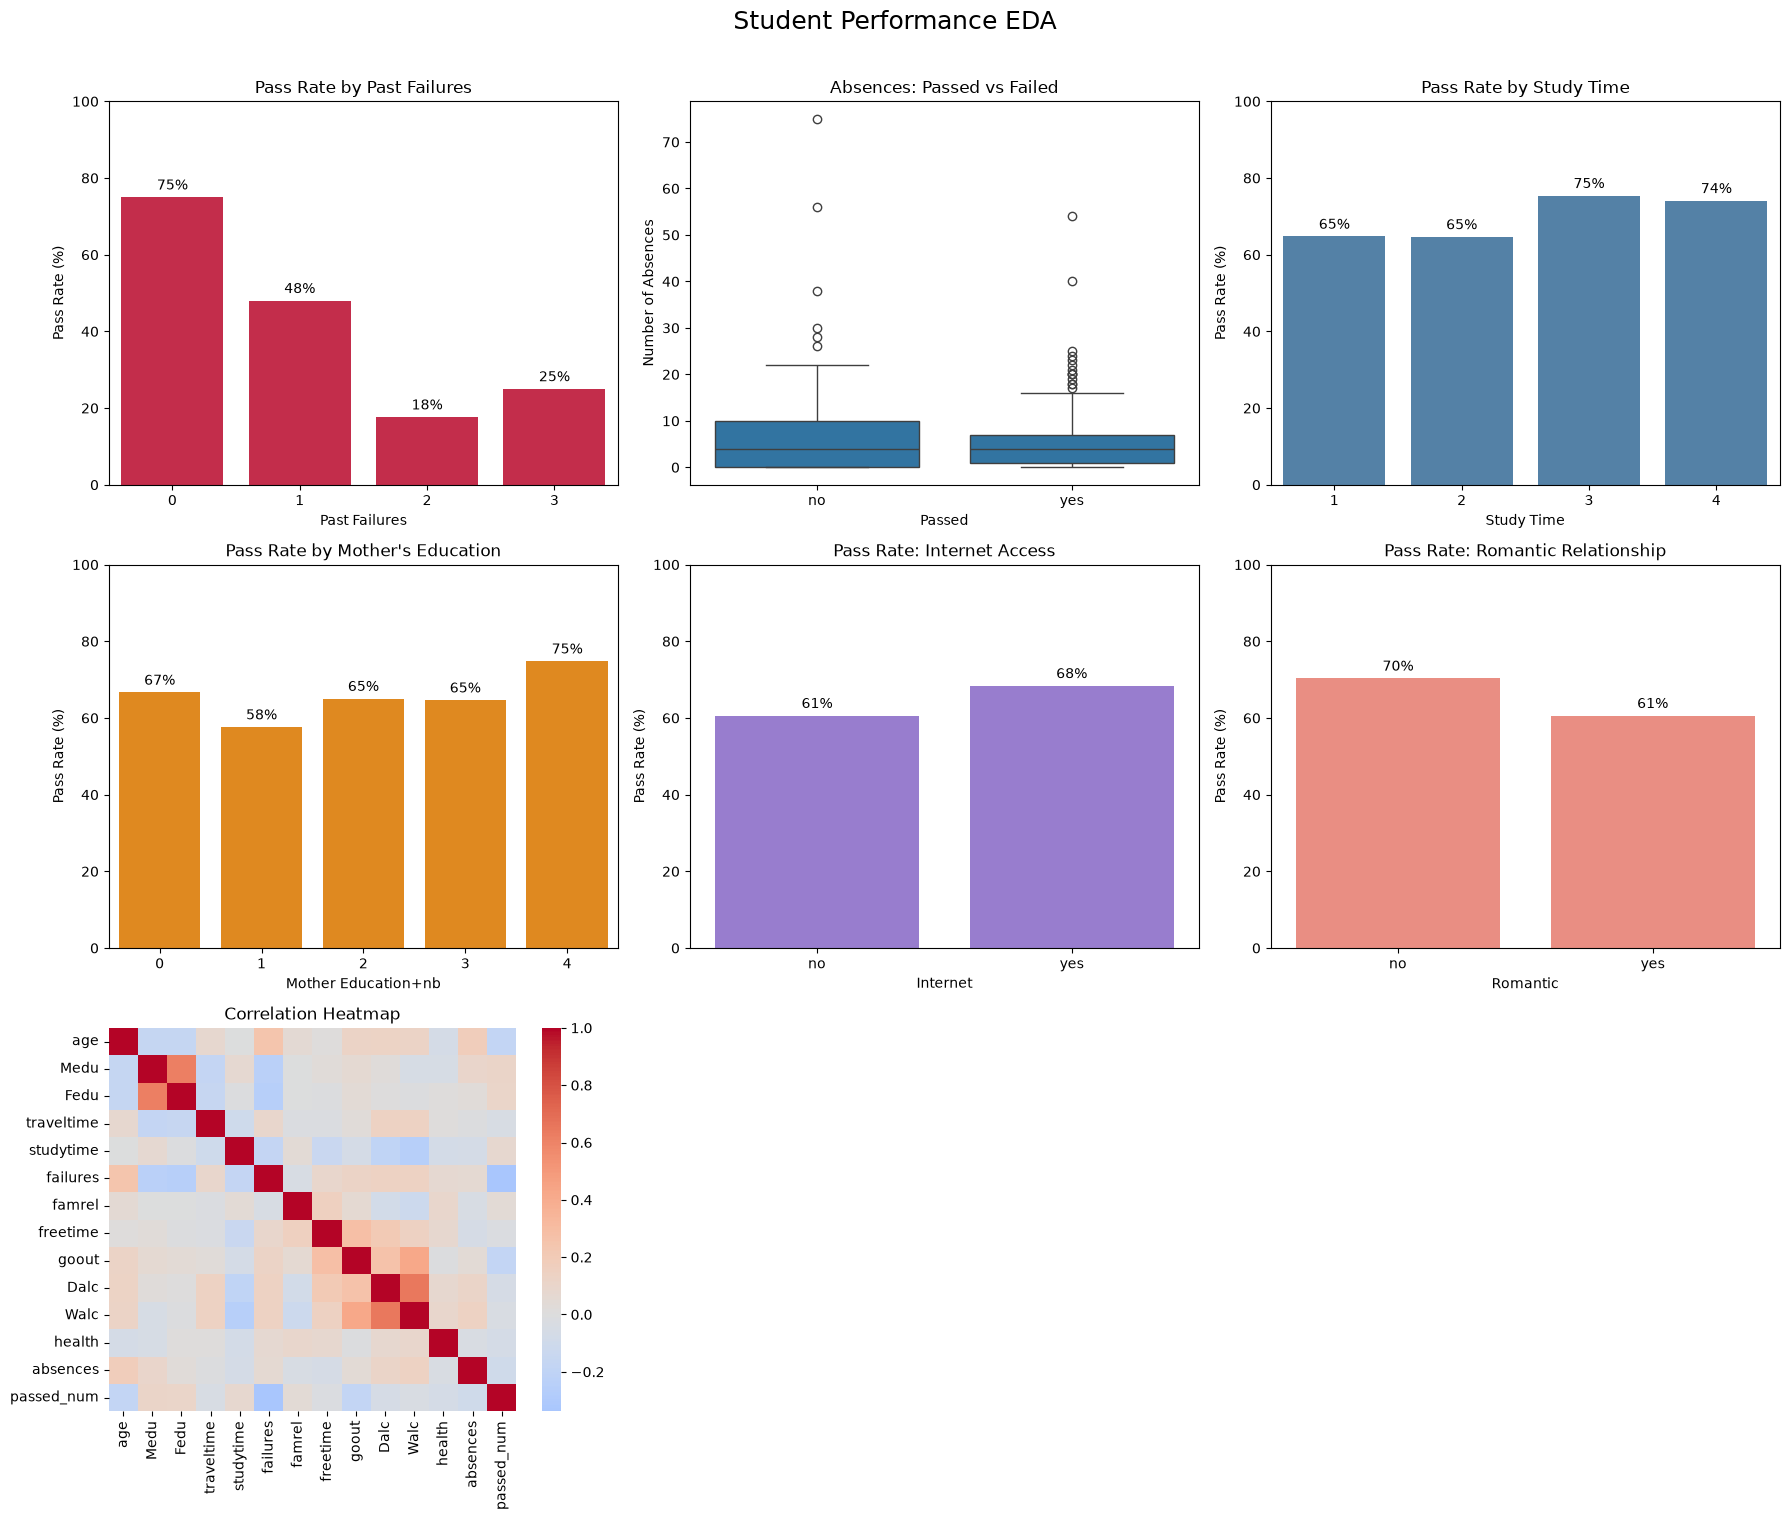

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("student-data.csv")
df["passed_num"] = (df["passed"] == "yes").astype(int)

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(3, 3, figsize=(18, 15))


def bar_with_labels(ax, series_pct, title, xlabel, color):
    sns.barplot(x=series_pct.index, y=series_pct.values, ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Pass Rate (%)")
    ax.set_ylim(0, 100)
    for i, v in enumerate(series_pct.values):
        ax.text(i, v + 2, f"{v:.0f}%", ha="center")


#Pass rate by past failures 
rates = df.groupby("failures")["passed_num"].mean() * 100
bar_with_labels(ax1, rates, "Pass Rate by Past Failures", "Past Failures", "crimson")

#Absences boxplot (this needs its OWN axis — ax2, not ax1) 
sns.boxplot(x="passed", y="absences", data=df, ax=ax2)
ax2.set_title("Absences: Passed vs Failed")
ax2.set_xlabel("Passed")
ax2.set_ylabel("Number of Absences")

#Pass rate by study time 
rates = df.groupby("studytime")["passed_num"].mean() * 100
bar_with_labels(ax3, rates, "Pass Rate by Study Time", "Study Time", "steelblue")

#Pass rate by mother's education 
rates = df.groupby("Medu")["passed_num"].mean() * 100
bar_with_labels(ax4, rates, "Pass Rate by Mother's Education", "Mother Education+nb", "darkorange")

#Pass rate by internet access 
rates = df.groupby("internet")["passed_num"].mean() * 100
bar_with_labels(ax5, rates, "Pass Rate: Internet Access", "Internet", "mediumpurple")

#Pass rate by romantic relationship 
rates = df.groupby("romantic")["passed_num"].mean() * 100
bar_with_labels(ax6, rates, "Pass Rate: Romantic Relationship", "Romantic", "salmon")

#Correlation heatmap
numeric_cols = [
    "age", "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health",
    "absences", "passed_num"
]
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax7, cbar=True)
ax7.set_title("Correlation Heatmap")

ax8.axis("off")
ax9.axis("off")

fig.suptitle("Student Performance EDA", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()